#AdventureWorks Analys

I denna analys undersöker vi AdventureWorks-databasen för att besvara affärsfrågor som exempelvis:
- Produktkategorier och deras försäljning
- Försäljningstränder över tid
- Regional försäljning

Vi använder sql för att hämta data och python för visualisering och analys.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sqlalchemy import create_engine, text
from urllib.parse import quote_plus


user = "SA"
password = quote_plus("BytMig123!")
server = "localhost:1433"
database = "AdventureWorks"
driver = quote_plus("ODBC Driver 18 for SQL server")


connection_string = (
    f"mssql+pyodbc://{user}:{password}@{server}/{database}"
    f"?driver={driver}&Encrypt=yes&TrustServerCertificate=yes"
)

engine = create_engine(connection_string)

try:
    with engine.connect():
        print("Success")
except Exception as e:
    print("Error", e)        


Success


C:\Users\dropz\AppData\Local\Temp\ipykernel_29272\4032200843.py:23: SAWarning: Unrecognized server version info '17.0.1000.7'.  Some SQL Server features may not function properly.
  with engine.connect():


In [2]:
def query_df(sql: str):
    with engine.connect() as conn:
        return pd.read_sql(text(sql), conn)

## Visualisering 1: Antal produkter per kategori
hur många produkter finns i varje kategori?

Tabeller som används:
Production.ProductCategory
Production.ProductSubcategory
Production.Product

Plan:
Joina tabellerna
Räkna DISTINCT produkter per kategori
Skapa vertikalt stapeldiagram
Analysera resultatet



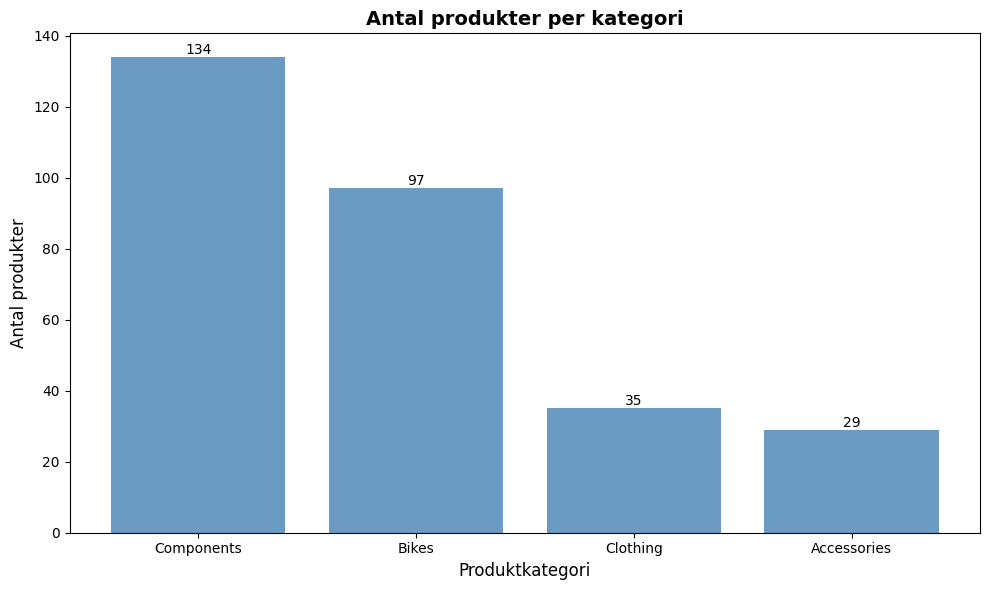

In [3]:
query_vis1 = """
SELECT
    pc.Name AS CategoryName,
    COUNT(DISTINCT p.ProductID) AS ProductCount
    
FROM production.ProductCategory pc
INNER JOIN Production.ProductSubcategory psc ON pc.ProductCategoryID = psc.ProductCategoryID
INNER JOIN Production.Product p ON psc.ProductSubcategoryID = p.ProductSubcategoryID
GROUP BY pc.Name
ORDER BY ProductCount DESC
"""

df_vis1 = query_df(query_vis1)


fig, ax = plt.subplots(figsize=(10,6))


bars = ax.bar (df_vis1['CategoryName'],df_vis1['ProductCount'], color='steelblue', alpha=0.8)
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{int(height)}',
        ha='center',
        va='bottom'    
    )
  

ax.set_xlabel('Produktkategori', fontsize=12)
ax.set_ylabel('Antal produkter', fontsize=12)
ax.set_title('Antal produkter per kategori', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()



### Insikter - Antal produkter perkategori
Components är största kategorin med 134 produkter.
Accessories är minst med 29 produkter.
Detta indikerar att företaget är starkt fokuserat på komponenter och reservdelar.
Och att accessories kan vara ett utvecklingsområde.

## Visualisering 2 = Försäljning per produktkategori.

Vilka produktkategorier genererar mest intäkter?

Tabeller som används:

Production.ProductCategory 
Production.ProductSubcategory
Production.Product
Sales.SalesOrderDetail

Plan:
Joina tabellerna
Sortera från högst till lägst försäljning
Skapa horisontellt stapeldiagram
Analysera resultatet



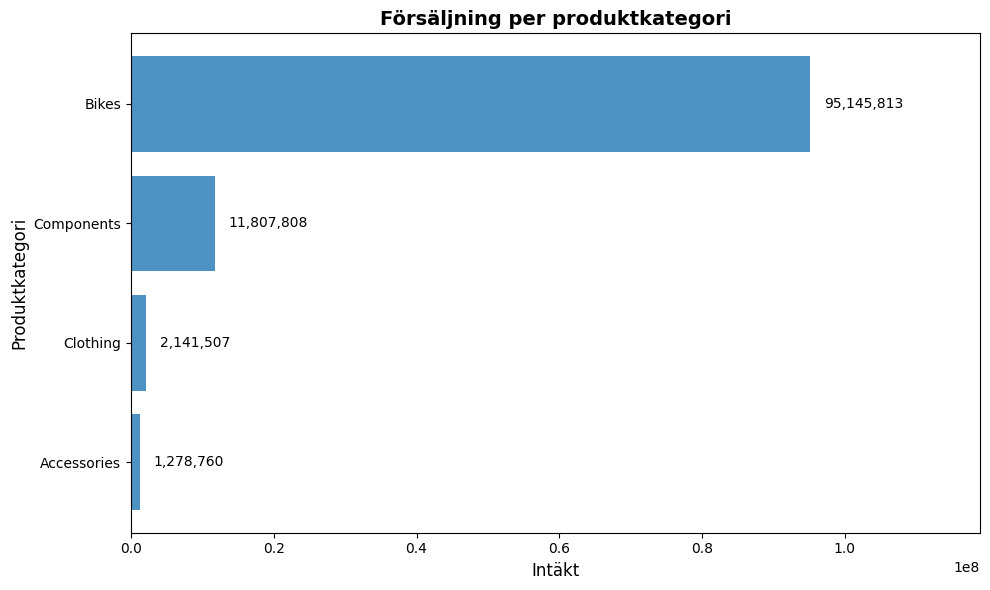

In [4]:
query_vis2 = """
SELECT
    pc.Name AS CategoryName,
    SUM(sod.OrderQty * sod.UnitPrice) AS TotalRevenue
    
FROM Production.ProductCategory pc
INNER JOIN Production.ProductSubcategory psc ON pc.ProductCategoryID = psc.ProductCategoryID
INNER JOIN Production.Product p ON psc.ProductSubcategoryID = p.ProductSubcategoryID
INNER JOIN Sales.SalesOrderDetail sod ON sod.ProductID = p.ProductID
GROUP BY pc.Name
ORDER BY TotalRevenue DESC
"""

df_vis2 = query_df(query_vis2)


df_vis2["TotalRevenue"] = pd.to_numeric(df_vis2["TotalRevenue"])

fig, ax = plt.subplots(figsize=(10,6))

bars = ax.barh(df_vis2["CategoryName"], df_vis2["TotalRevenue"], alpha=0.8)


ax.invert_yaxis()

max_val = df_vis2["TotalRevenue"].max()


ax.set_xlim(0, max_val * 1.25)

for bar in bars:
    width = bar.get_width()
    ax.text(
        width + max_val * 0.02,                
        bar.get_y() + bar.get_height()/2,
        f"{int(width):,}",                      
        va="center",
        ha="left"
    )

ax.set_xlabel("Intäkt", fontsize=12)
ax.set_ylabel("Produktkategori", fontsize=12)
ax.set_title("Försäljning per produktkategori", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.show()



### Insikter  -  Försäljning per produktkategori

Bikes är den kategori som genererar mest intekter och acessories ger minst intäkter.

Detta indikerar att cyklar står för den största delen av företagets omsättning.
accessories genererar ganska lite pengar och behöver pushas lite för att öka försäljningen.

## Visualisering 3 Försäljningstrend över tid.

Hur har försäljningen utvecklats över tid?

Tabeller som används: 

Sales.SalesOrderHeader

Plan:

Aggregera per månad (minst 12 månader data)
Sortera kronologiskt (äldst först)
Göra Linjediagram som visar en tydlig tidslinje
och beskriver om trenden ökar minskar är sesongsberoende och visar högsta och lägsta månaden


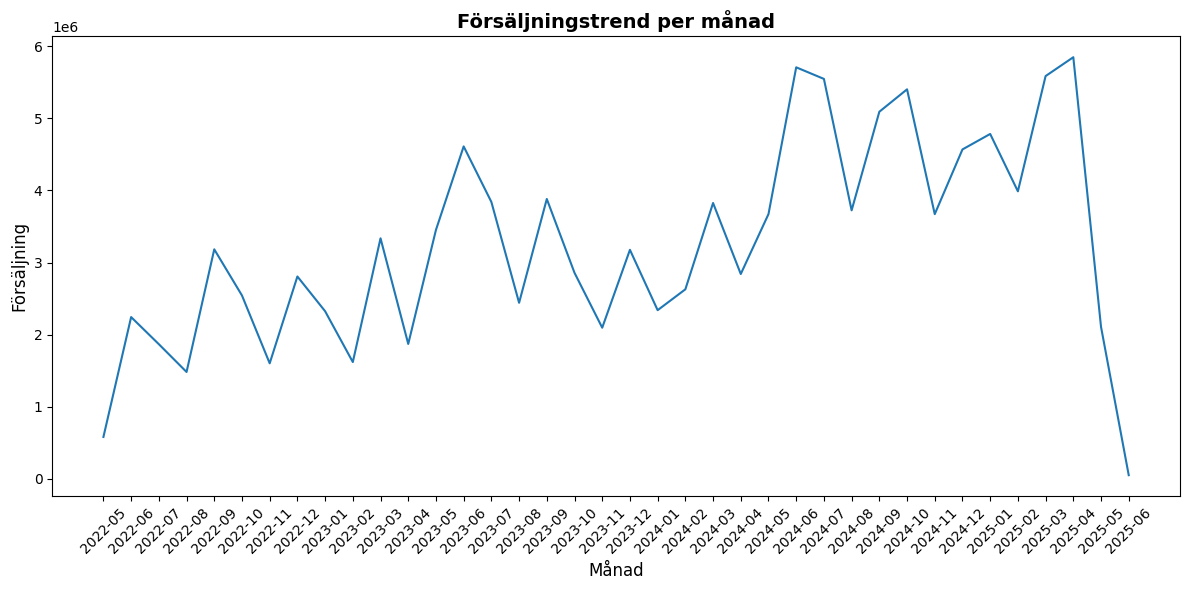

Högsta månad: 2025-04 (5,847,165)
Lägsta månad: 2025-06 (52,478)
Antal månader i data: 38


In [5]:
query_vis3 = """
SELECT
    FORMAT(soh.OrderDate, 'yyyy-MM') AS YearMonth,
    SUM(soh.TotalDue) AS TotalSales
FROM Sales.SalesOrderHeader soh
GROUP BY FORMAT(soh.OrderDate, 'yyyy-MM')
ORDER BY YearMonth
"""

df_vis3 = query_df(query_vis3)
df_vis3["TotalSales"] = pd.to_numeric(df_vis3["TotalSales"])
df_vis3.head()

fig, ax = plt.subplots(figsize=(12,6))

ax.plot(df_vis3["YearMonth"], df_vis3["TotalSales"])

ax.set_xlabel("Månad", fontsize=12)
ax.set_ylabel("Försäljning", fontsize=12)
ax.set_title("Försäljningstrend per månad", fontsize=14, fontweight="bold")


ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


max_row = df_vis3.loc[df_vis3["TotalSales"].idxmax()]
min_row = df_vis3.loc[df_vis3["TotalSales"].idxmin()]

print(f"Högsta månad: {max_row['YearMonth']} ({max_row['TotalSales']:,.0f})")
print(f"Lägsta månad: {min_row['YearMonth']} ({min_row['TotalSales']:,.0f})")

print("Antal månader i data:", len(df_vis3))




## insikter försäljning över tid
Försäljningen varierarmellan månader  och visar en trend  över tid och visar att 
försäljningen kan vara säsongsberoende  med perioder av högre och lägre försäljning. högsta månaden var 2025-04  och den lägsta var  2025-06 

## Visualisering 4 Försäljning och antal ordrar per år

Hur ser totalförsäljning och antal ordrar ut per år?

Tabeller som används :

Sales.SalesOrderHeader

plan:

Visa både total försäljning OCH antal ordrar
Gruppera per år
Sortera kronologiskt
visa i grupperat stapeldiagram

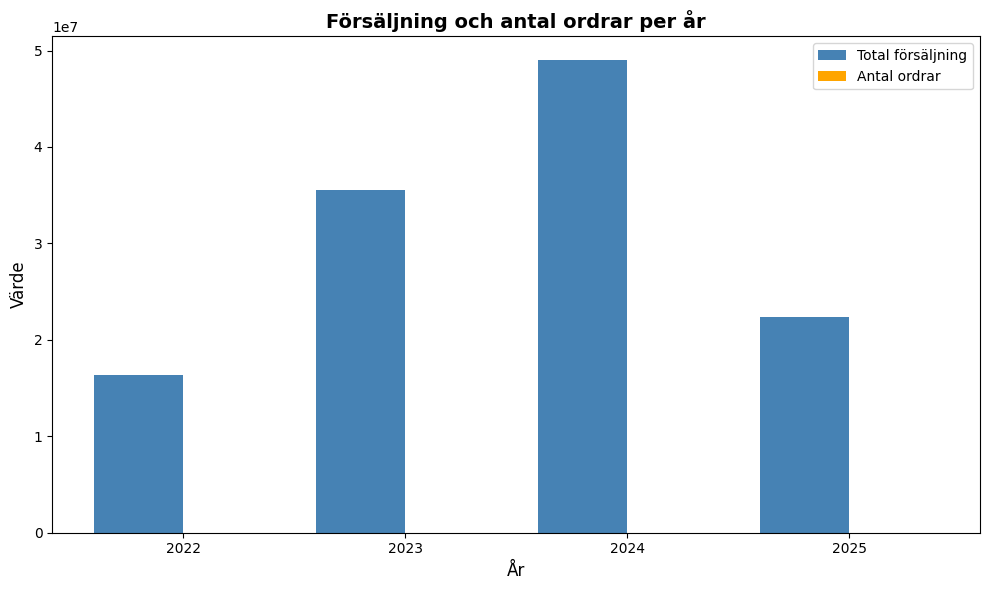

Högst försäljning: 2024
Flest ordrar: 2024
Försäljningen ökar över tid.
Antal ordrar ökar över tid.


In [6]:
query_vis4 = """
SELECT
    YEAR(OrderDate) AS OrderYear,
    COUNT(SalesOrderID) AS NumberOfOrders,
    SUM(TotalDue) AS TotalSales
FROM Sales.SalesOrderHeader
GROUP BY YEAR(OrderDate)
ORDER BY OrderYear
"""
df_vis4 = query_df(query_vis4)
df_vis4


years = df_vis4["OrderYear"].astype(str)
sales = df_vis4["TotalSales"]
orders = df_vis4["NumberOfOrders"]

x = np.arange(len(years))
bar_width = 0.4

fig, ax = plt.subplots(figsize=(10,6))

ax.bar(x - bar_width/2, sales, width=bar_width, color="steelblue", label="Total försäljning")
ax.bar(x + bar_width/2, orders, width=bar_width, color="orange", label="Antal ordrar")


ax.set_xlabel("År", fontsize=12)
ax.set_ylabel("Värde", fontsize=12)
ax.set_title("Försäljning och antal ordrar per år", fontsize=14, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(years)

ax.legend()
plt.tight_layout()
plt.show()




max_sales_year = df_vis4.loc[df_vis4["TotalSales"].idxmax(), "OrderYear"]
max_orders_year = df_vis4.loc[df_vis4["NumberOfOrders"].idxmax(), "OrderYear"]

sales_up = df_vis4["TotalSales"].iloc[-1] > df_vis4["TotalSales"].iloc[0]
orders_up = df_vis4["NumberOfOrders"].iloc[-1] > df_vis4["NumberOfOrders"].iloc[0]

print(f"Högst försäljning: {max_sales_year}")
print(f"Flest ordrar: {max_orders_year}")
print(f"Försäljningen {'ökar' if sales_up else 'minskar/varierar'} över tid.")
print(f"Antal ordrar {'ökar' if orders_up else 'minskar/varierar'} över tid.")


## insikt - Försäljning och antal ordrar per år

Försäljningen ökar varje år och är som högst år 2024.
antalet ordrar ökar också över tid vilket betyder att företaget får fler ordrar och mer pengar per år 

## Visualisering 5 Top 10 produkter

Vilka produkter genererar mest försäljning?

Tabeller som används:

Production.Product, Sales.SalesOrderDetail

plan:

visa endast Top 10 produkter
sortera högst till lägst
horisontellt stapeldiagram som är sorterade högst till lägst

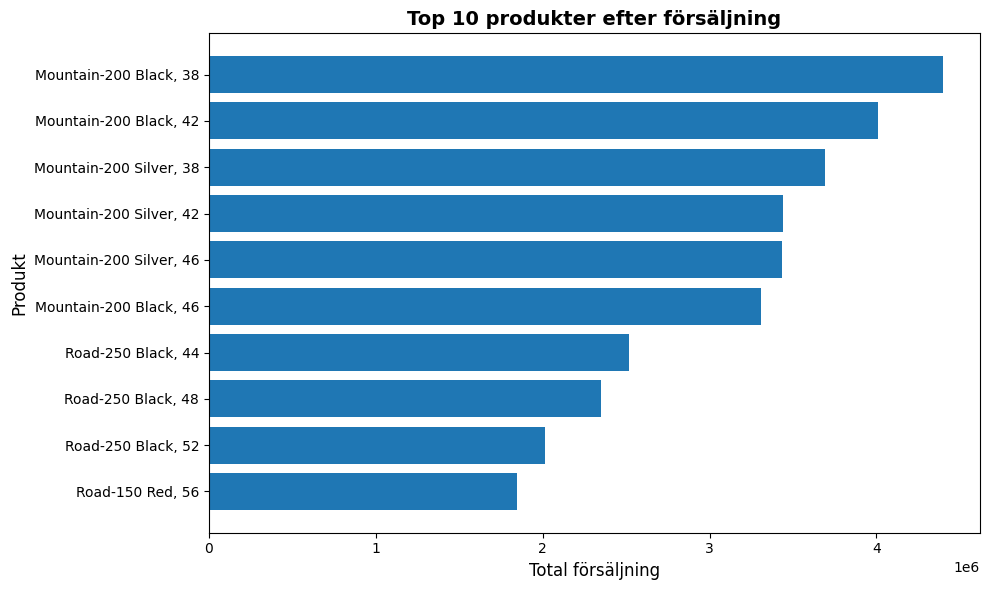

#1 produkt: Mountain-200 Black, 38
Exakt försäljningsvärde: 4400592.8004


In [7]:
query_vis5 = """
SELECT TOP 10
    p.Name AS ProductName,
    SUM(sod.LineTotal) AS TotalSales
FROM Production.Product p
JOIN Sales.SalesOrderDetail sod
    ON p.ProductID = sod.ProductID
GROUP BY p.Name
ORDER BY TotalSales DESC
"""
df_vis5 = query_df(query_vis5)
df_vis5




df_plot = df_vis5.iloc[::-1]  

fig, ax = plt.subplots(figsize=(10,6))

ax.barh(df_plot["ProductName"], df_plot["TotalSales"])

ax.set_xlabel("Total försäljning", fontsize=12)
ax.set_ylabel("Produkt", fontsize=12)
ax.set_title("Top 10 produkter efter försäljning", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.show()


top_product = df_vis5.loc[0, "ProductName"]
top_sales = df_vis5.loc[0, "TotalSales"]

print(f"#1 produkt: {top_product}")
print(f"Exakt försäljningsvärde: {top_sales}")

#1 produkten är [produktnamn] med total försäljning [exakt värde].


## Insikt top 10 produkter

# 1 Produkten som genererar mest försäljning är Mountain - 200 black 38
exakt föräljningsvärde 4400592.8004